## **Dataset Overview**
- **Tên dataset**: Online Retail UCI
- **Nguồn**: UCI Machine Learning Repository
-  **Link dataset**: https://archive.ics.uci.edu/dataset/352/online+retail
- **Lĩnh vực**: E-commerce, ngành bán lẻ UK chuyên quà tặng độc đáo
- **Quy mô**: 541,909 giao dịch
- **Giai đoạn thời gian**: 01/12/2009 đến 09/12/2011
- **Phạm vi**: Giao dịch toàn cầu với tập trung vào thị trường UK


### Đọc dữ liệu từ file CSV


In [15]:
import sys
import os
import pandas as pd
sys.path.insert(0, os.path.abspath('..'))
from src.processors.csv_processor import CSVProcessor
from src.processors.csv_eda import CsvEDA
from src.utilities.eda_visualizer import EDAVisualizer
from src.orchestrators.eda_orchestractor import EDAOrchestrator
from src.utilities.convert_data_type import ConvertDataType

RAW_PATH = '../data/raw/online_retail.csv'
EXPORT_PATH = '../data/processed/clean_transactions.csv'
TARGET_COUNTRY = 'United Kingdom'
EDA_RESULTS_PATH = '../data/processed/eda_results/'

processor = CSVProcessor(input_path=RAW_PATH)

data = processor.read()
print(f"Kích thước dữ liệu ban đầu: {data.shape}")
print(f"Số giao dịch: {data.shape[0]}")
display(data.head())

Kích thước dữ liệu ban đầu: (541909, 8)
Số giao dịch: 541909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


###  Thông tin cơ bản về dataset
- Tên cột và kiểu dữ liệu của từng cột 
- Số lượng khách
- Top quốc gia nhiều giao dịch nhất



In [16]:
print("Thông tin tổng quan:")
print(f"- Kích thước: {data.shape[0]:,} dòng x {data.shape[1]} cột")
print(f"- Tổng số khách: {data['CustomerID'].nunique()} khách")
print(f"- Top 3 quốc gia nhiều giao dịch nhất: \n{data['Country'].value_counts().head(3).to_string()}")
print()
data.info()


Thông tin tổng quan:
- Kích thước: 541,909 dòng x 8 cột
- Tổng số khách: 4372 khách
- Top 3 quốc gia nhiều giao dịch nhất: 
Country
United Kingdom    495478
Germany             9495
France              8557

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


### Bảng mô tả ý nghĩa của từng cột

| Tên cột | Ý nghĩa trong dự án | Kiểu dữ liệu mong muốn | Ghi chú|
|---|---|---|---|
| InvoiceNo | Mã hóa đơn/giao dịch. Bắt đầu bằng chữ C là đơn hàng hủy | object/string |Dùng để đếm số đơn hàng và phát hiện đơn hàng bị canceled | 
| StockCode | Mã sản phẩm | object/string | Dùng để phân tích sản phẩm bán chạy |
| Description | Tên/mô tả sản phẩm | object/string | Có thể thiếu ở raw data; không phải cột cốt lõi để tính RFM |
| Quantity | Số lượng sản phẩm trong hóa đơn. Số âm là giao dịch bị hủy | interger | Phải > 0 sau khi làm sạch cho giao dịch mua hợp lệ |
| InvoiceDate | Thời điểm phát sinh hóa đơn | DateTime |Dùng để tính Recency và phân tích doanh thu theo thời gian |
| UnitPrice | Giá trên một đơn vị sản phẩm | Float  | Phải > 0 sau khi làm sạch |
| CustomerID | Mã khách hàng | string  | Bắt buộc cho Customer Segmentation/RFM. Dòng thiếu CustomerID sẽ bị loại |
| Country | Quốc gia của khách hàng/giao dịch | object/string | Dùng để EDA theo thị trường |
| TotalPrice | Doanh thu dòng giao dịch = Quantity × UnitPrice | float | Cột tạo mới sau cleaning |

### Kiểm tra xử lý dữ liệu thiếu theo cột

In [17]:
df_uk = processor.filter_by_country(data, country=TARGET_COUNTRY)
#del data
uk_size_bf = df_uk.shape
uk_customer_bf = df_uk['CustomerID'].nunique()

missing_report= df_uk.isnull().sum().to_frame(name='Missing Values')
print("Báo cáo missing values:")
display(missing_report)

subsets= ['CustomerID']
df_uk = processor.handle_missing_values(df_uk, subsets=subsets)

print(f"\nDữ liệu trước khi xử lý: {uk_size_bf[0]} dòng x {uk_size_bf[1]} cột")
print(f"\nDữ liệu sau khi xử lý missing: {df_uk.shape[0]} dòng x {df_uk.shape[1]} cột")

Báo cáo missing values:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,133600
Country,0



Dữ liệu trước khi xử lý: 495478 dòng x 8 cột

Dữ liệu sau khi xử lý missing: 361878 dòng x 8 cột


### Kiểm tra giao dịch bị trùng 

In [18]:
df_uk = ConvertDataType(column_name='CustomerID', target_type=int).convert(df_uk)
df_uk = ConvertDataType(column_name='CustomerID', target_type=str).convert(df_uk)
df_uk = ConvertDataType(column_name='InvoiceDate', target_type='datetime').convert(df_uk)
print("Báo cáo chuyển đổi kiểu dữ liệu:")
display(df_uk[['CustomerID', 'InvoiceDate']].dtypes.to_frame(name='Data Types'))

subsets = ['InvoiceNo', 'StockCode']
duplicate_mask = df_uk.duplicated(subset=subsets, keep=False)
sum_duplicates = duplicate_mask.sum()
print(f"Số giao dịch trùng theo InvoiceNo và StockCode: {sum_duplicates}")
display(df_uk[duplicate_mask].head())

df_uk = processor.handle_duplicates(df_uk, subsets=subsets)
print(f"\nKích thước sau khi loại bỏ trùng: {df_uk.shape[0]} dòng x {df_uk.shape[1]} cột")

Báo cáo chuyển đổi kiểu dữ liệu:


,Data Types
CustomerID,str
InvoiceDate,datetime64[us]


Số giao dịch trùng theo InvoiceNo và StockCode: 19023


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311,United Kingdom
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01 11:45:00,6.35,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom



Kích thước sau khi loại bỏ trùng: 351898 dòng x 8 cột


### Kiểm tra và xử lý giao dịch bị hủy 

In [19]:
canceled_mask = df_uk['InvoiceNo'].str.startswith('C')
sum_canceled = canceled_mask.sum()
print(f"Số giao dịch bị hủy: {sum_canceled}")
display(df_uk[canceled_mask].head())

df_uk = processor.handle_cancelled_transactions(df_uk, key='InvoiceNo', character='C')
print(f"Dữ liệu sau khi loại cancelled: {df_uk.shape[0]} dòng x {df_uk.shape[1]} cột")

Số giao dịch bị hủy: 7443


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
120,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
133,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
200,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
201,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
202,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


Dữ liệu sau khi loại cancelled: 344455 dòng x 8 cột


### Kiểm tra và xử lý Quantity và UnitPrice âm

In [20]:
invalid_qty = (df_uk['Quantity'] <= 0).sum()
print(f"Tổng số hàng có Quantity âm: {invalid_qty}")

invalid_price = (df_uk['UnitPrice'] <= 0).sum()
print(f"Tổng số hàng có UnitPrice âm: {invalid_price}")

print(f"\nDữ liệu sau khi loại invalid: {df_uk.shape[0]} dòng x {df_uk.shape[1]} cột")

Tổng số hàng có Quantity âm: 0
Tổng số hàng có UnitPrice âm: 22

Dữ liệu sau khi loại invalid: 344455 dòng x 8 cột


### Tạo cột TotalPrice = Quantity * UnitPrice

In [21]:
df_uk = processor.create_total_price_column(df_uk)
display(df_uk.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Xuất cleaned dataset = clean_transactions.csv

In [22]:
print(f"Kích thược UK ban đầu : {uk_size_bf[0]} dòng x {uk_size_bf[1]} cột")
print(f"Kích thước UK sau cleaning: {df_uk.shape[0]:,} dòng x {df_uk.shape[1]} cột")
print(f"Tổng số khách UK trước làm sạch: {uk_customer_bf} khách")
print(f"Tổng số khách UK sau làm sạch: {df_uk['CustomerID'].nunique()} khách")
print(f"Tỷ lệ dữ liệu bị loại bỏ: {((uk_size_bf[0] - df_uk.shape[0]) / uk_size_bf[0] * 100):.2f}%")

output_path = "../data/processed/clean_transactions.csv"
processor.export(df_uk, output_path)

Kích thược UK ban đầu : 495478 dòng x 8 cột
Kích thước UK sau cleaning: 344,455 dòng x 9 cột
Tổng số khách UK trước làm sạch: 3950 khách
Tổng số khách UK sau làm sạch: 3921 khách
Tỷ lệ dữ liệu bị loại bỏ: 30.48%
Đã lưu file cleaned thành công tại: ../data/processed/clean_transactions.csv
Kích thước cuối cùng: 344455 dòng x 9 cột
Số khách hàng cuối cùng: 3921


## EDA - Phân tích khám phá cơ bản

### Doanh thu theo thời gian
- Theo tháng
- Theo quý

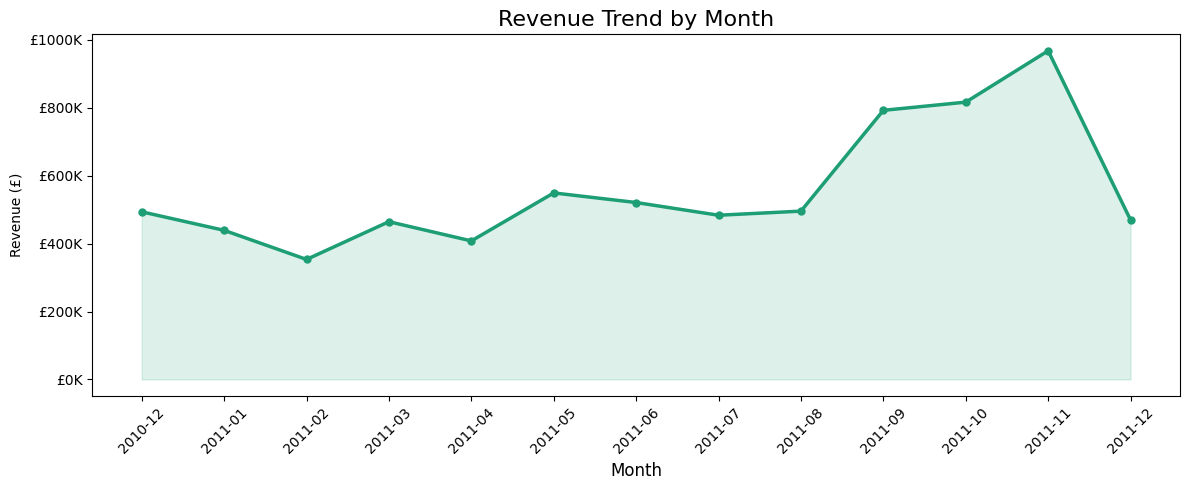

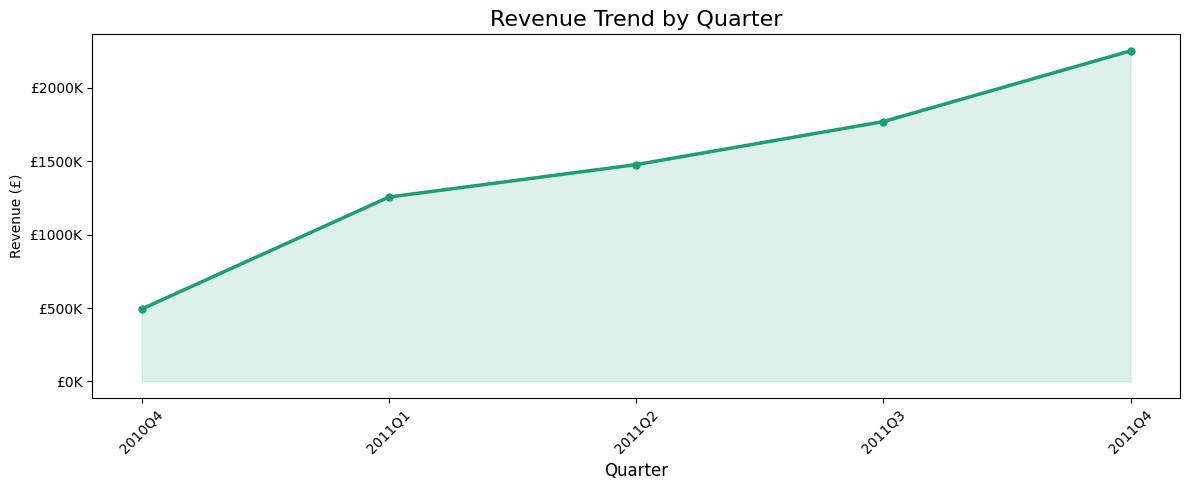

In [23]:
analyzer = CsvEDA(pd.read_csv(EXPORT_PATH))
df = analyzer.load_data() 
df = ConvertDataType(column_name='CustomerID', target_type=int).convert(df)
df = ConvertDataType(column_name='CustomerID', target_type=str).convert(df)
df = ConvertDataType(column_name='InvoiceDate', target_type='datetime').convert(df)
EDAOrchestrator = EDAOrchestrator(analyzer=analyzer, visualizer=EDAVisualizer())

results = {'figures': {}}

fig_m, _ = EDAOrchestrator.revenue_trend_orchestrator(df, freq='M')
results['figures']['revenue_trend_monthly'] = fig_m

fig_q, _ = EDAOrchestrator.revenue_trend_orchestrator(df, freq='Q')
results['figures']['revenue_trend_quarterly'] = fig_q

### Phân tích thời gian mua hàng
- Ngày trong tuần
- Giờ trong ngày

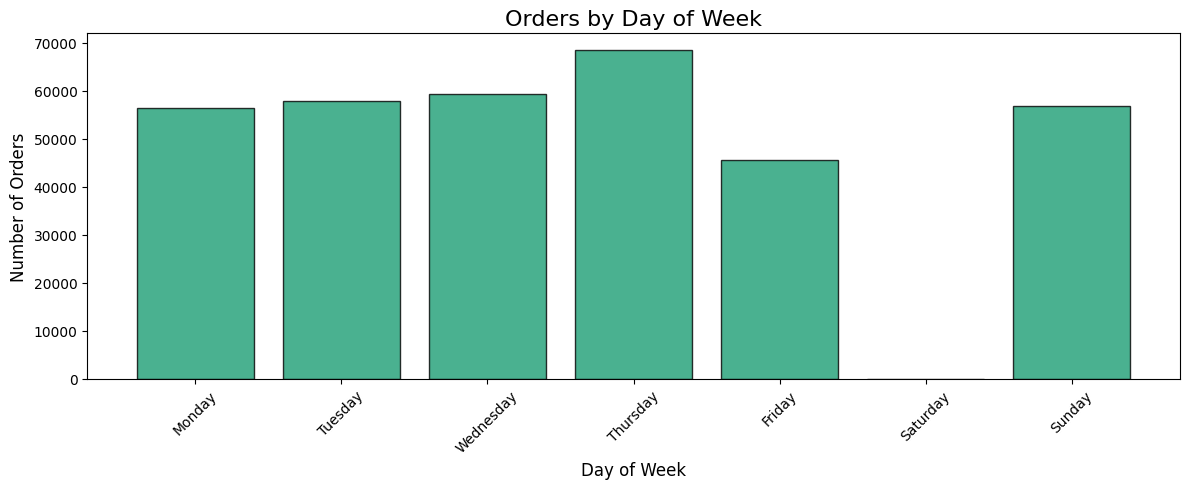

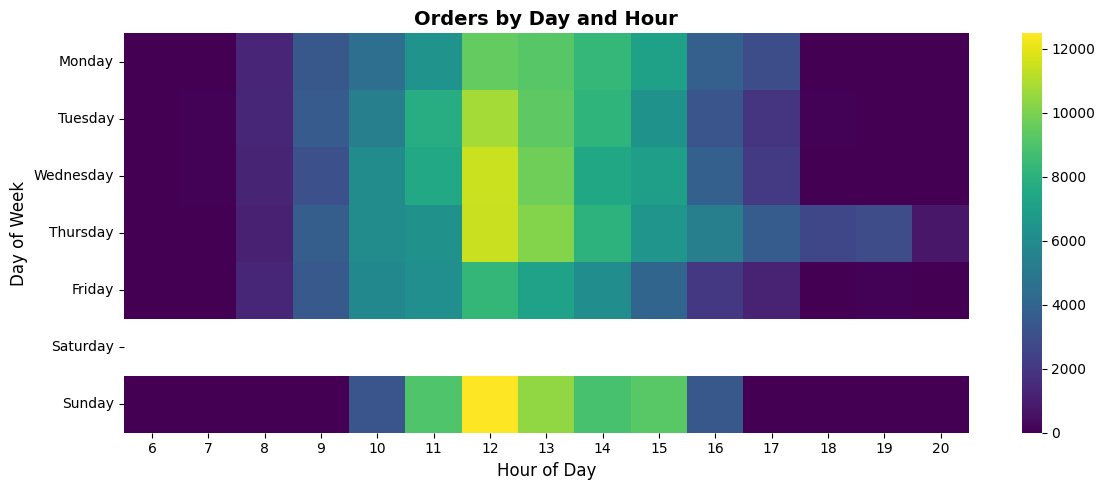

In [24]:
fig_wd, _ = EDAOrchestrator.orders_by_trend_orchestrator(df, freq='weekday')
results['figures']['orders_by_weekday'] = fig_wd

fig_h, _ = EDAOrchestrator.orders_by_trend_orchestrator(df, freq='hour')
results['figures']['orders_by_hour'] = fig_h

### Top sản phầm 
- Theo doanh thu - mang lại lợi nhuận
- Theo số lượng - bán chạy nhất

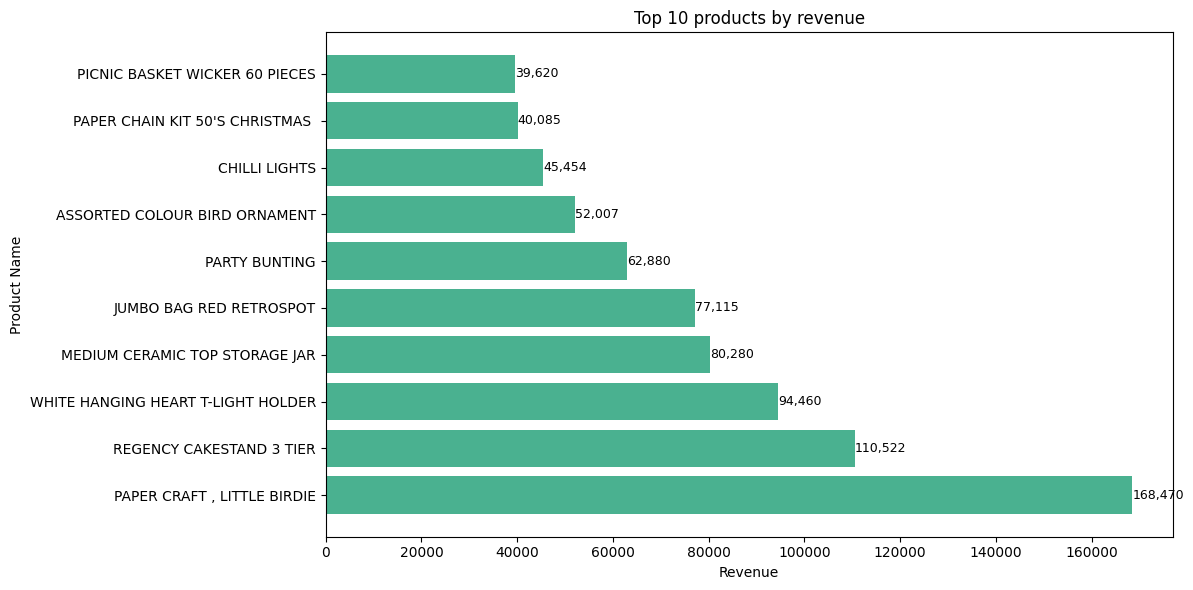

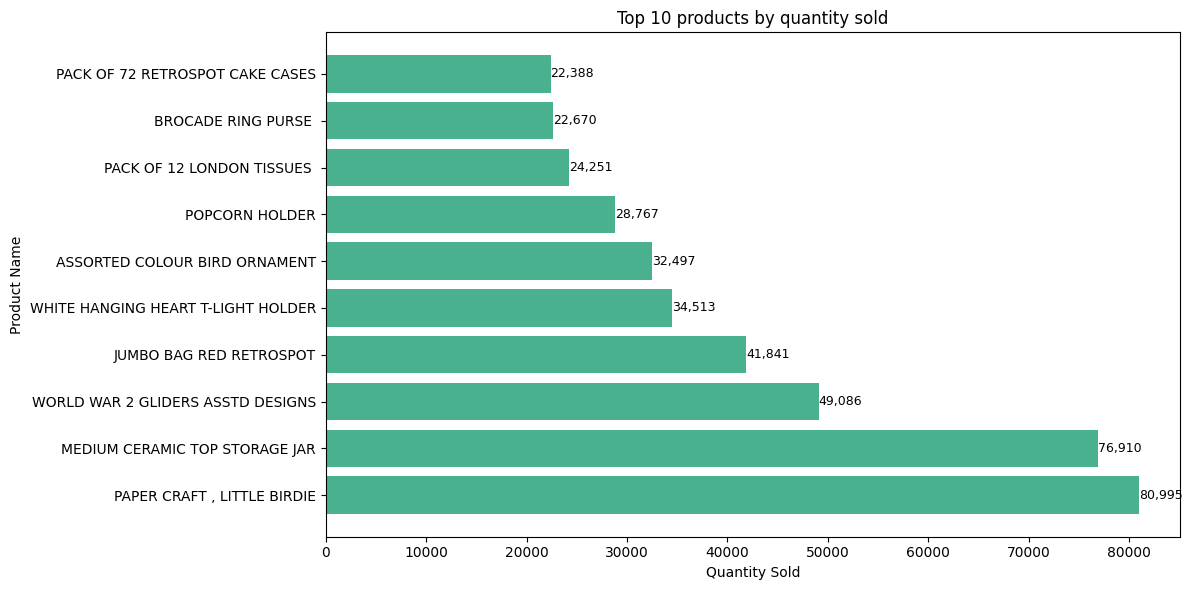

In [25]:
fig_rev, _ = EDAOrchestrator.top_products_orchestrator(df, top_n=10, by='revenue')
results['figures']['top_products_revenue'] = fig_rev

fig_qty, _ = EDAOrchestrator.top_products_orchestrator(df, top_n=10, by='quantity')
results['figures']['top_products_quantity'] = fig_qty

###d


 PHÂN TÍCH HÀNH VI KHÁCH HÀNG

 THỐNG KÊ CHUNG:
  Tổng số khách hàng : 3,921
  Tổng số đơn hàng   : 16,649
  Giá trị TB/đơn hàng: £435.50

 CHI TIÊU KHÁCH HÀNG:
  Số khách   : 3,921
  Trung bình : £1849.17
  Độ lệch chuẩn: £7469.45
  Tối thiểu  : £0.00
  25%ile     : £295.00
  Median     : £638.05
  75%ile     : £1562.40
  Tối đa     : £259,657.30

 HÀNH VI MUA HÀNG:
  Trung bình : 4.25 lần/khách
  Tối thiểu  : 1 lần
  Tối đa     : 210 lần


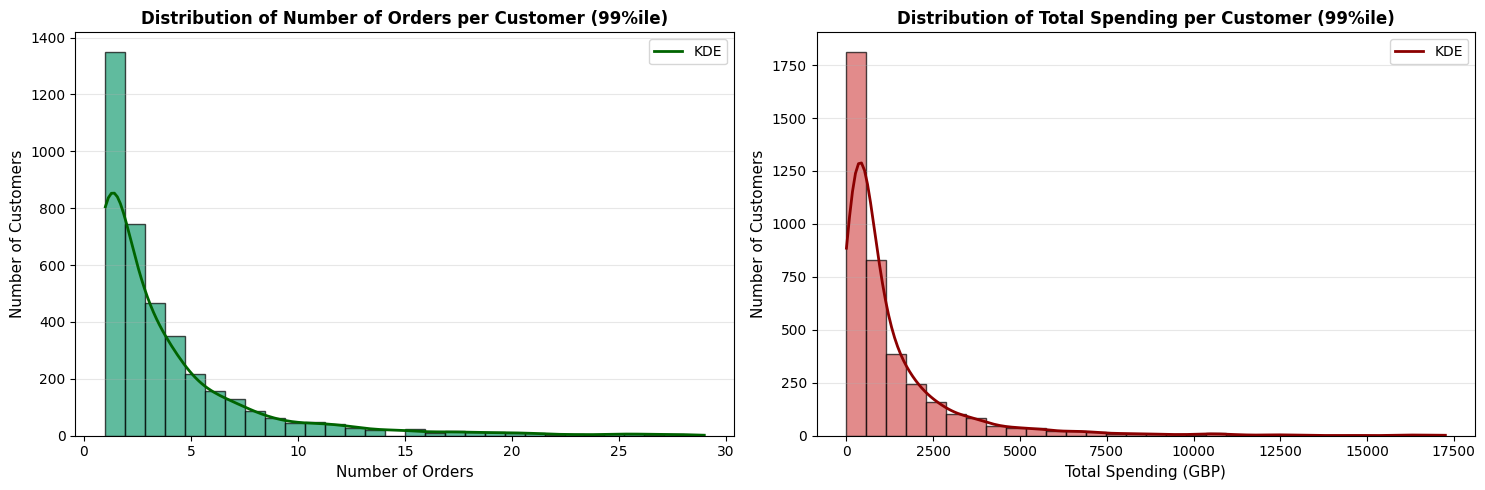

In [26]:
fig_cb, _ = EDAOrchestrator.customer_behavior_orchestrator(df)
results['figures']['customer_behavior'] = fig_cb

In [27]:
analyzer.export_results(results, output_path=EDA_RESULTS_PATH)


Export PNG: ../data/processed/eda_results/revenue_trend_monthly.png
Export PNG: ../data/processed/eda_results/revenue_trend_quarterly.png
Export PNG: ../data/processed/eda_results/orders_by_weekday.png
Export PNG: ../data/processed/eda_results/orders_by_hour.png
Export PNG: ../data/processed/eda_results/top_products_revenue.png
Export PNG: ../data/processed/eda_results/top_products_quantity.png
Export PNG: ../data/processed/eda_results/customer_behavior.png
